In [1]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
housing = fetch_california_housing()
X = housing.data
y = housing.target

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 增加偏置项（截距 b）
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

In [3]:
class MyRidgeRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000, lambda_param=0.1):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.lambda_param = lambda_param # L2 正则化强度参数
        self.weights = None
    
    def fit(self, X, y):
        n_features = X.shape[1]
        self.weights = np.random.randn(n_features) * 0.01
        
        for _ in range(self.n_iterations):
            y_pred = X.dot(self.weights)
            error = y_pred - y
            
            # 核心区别：计算梯度时加入 L2 惩罚项
            regularization_term = (self.lambda_param / len(y)) * self.weights
            regularization_term[0] = 0  # 偏置项（截距）不参与正则化惩罚
            
            gradient = (1 / len(y)) * X.T.dot(error) + regularization_term
            self.weights -= self.learning_rate * gradient
            
    def predict(self, X):
        return X.dot(self.weights)

In [4]:
ridge_model = MyRidgeRegression(learning_rate=0.1, n_iterations=2000, lambda_param=1.0)
ridge_model.fit(X_train_b, y_train)
y_pred_ridge = ridge_model.predict(X_test_b)

# 计算 MSE 和 R² 指标
mse_ridge = np.mean((y_test - y_pred_ridge)**2)
ss_res = np.sum((y_test - y_pred_ridge)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2_ridge = 1 - (ss_res / ss_tot)

print(f"带 L2 正则化的线性回归 MSE: {mse_ridge:.4f}")
print(f"带 L2 正则化的线性回归 R²: {r2_ridge:.4f}")

# 打印一下权重看看
print("\n岭回归模型权重:", ridge_model.weights[:5])

带 L2 正则化的线性回归 MSE: 0.5559
带 L2 正则化的线性回归 R²: 0.5758

岭回归模型权重: [ 2.07194694  0.8543362   0.12262591 -0.29422725  0.33902162]


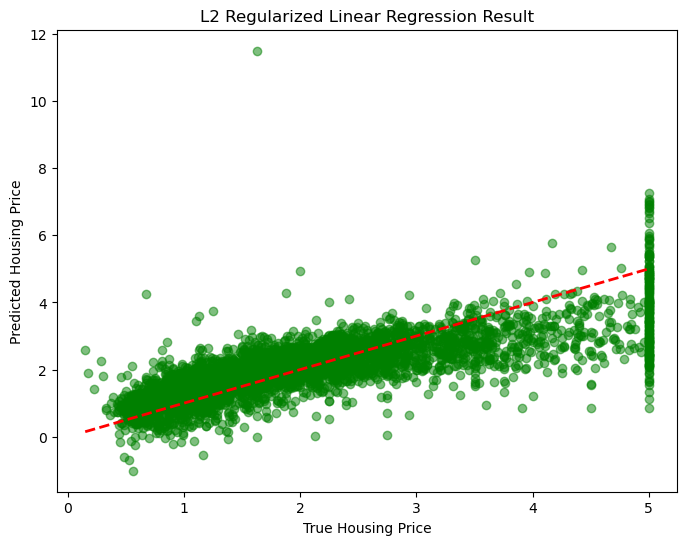

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.5, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) 
plt.xlabel("True Housing Price")  
plt.ylabel("Predicted Housing Price")  
plt.title("L2 Regularized Linear Regression Result")  
plt.show()